# Stream generation

This notebook demonstrates how to simulate a stellar stream from a dissolving globular cluster and verifies that the numerical integration is self-consistent.

The workflow proceeds as follows:

1. **Define a globular cluster** — a Plummer sphere with a chosen mass and half-mass radius, populated with star particles drawn from the ergodic distribution.
2. **Choose orbital initial conditions** — the cluster's center of mass is placed at apoapsis using pseudo-Keplerian parameters (radius, eccentricity, orientation angles).
3. **Integrate the cluster orbit backward in time** — the center of mass trajectory is computed from today back to an earlier epoch.
4. **Strip the stream forward** — star particles are initialized around the cluster's past position and integrated forward to today in the time-varying host potential, producing a tidal stream.
5. **Retrace the stream backward** — the final stream positions are integrated backward along the same host trajectory, recovering the original initial conditions.
6. **Evaluate energy conservation** — the fractional energy error $\left| (E_{\rm retrace} - E_0) / E_0 \right|$ is computed for each particle as a quantitative check.

Since the equations of motion are time-reversible, a well-implemented integrator should recover the initial conditions to within the numerical truncation error.

In [1]:
import tstrippy
import numpy as np 
import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 15,
})

## Define helper functions

A function for creating initial orbital conditions and viewing the geometry. 

`apoapsis_shot` - puts the particle at it's apoapsis, given the spherical coordinates and allows the user to modify the direction of the velocity vector and scale the speed down based on the circular velocity. 

`plot_initial_orbital_conditions_geometry` - shows the geometry as a check 


In [2]:
def apoapsis_shot(potential, params, radius, eccen, theta, phi, polar_mix, getVecs=False):
    """
    Generate initial position and velocity for an orbit launched from apogee.
    
    Uses pseudo-Keplerian parameters to construct phase-space coordinates
    in the Milky Way potential.
    
    Parameters
    ----------
    potential : function 
        tstrippy.potentials.pouliasis2017pii()
    params : array-like
        Potential parameters (from tstrippy.Parsers.pouliasis2017pii())
    radius : float
        Distance from galactic center (kpc)
    eccen : float
        Eccentricity-like speed scaling, 0 ≤ eccen < 1.
        At eccen=0, speed = circular speed. At eccen→1, speed→0.
    theta : float
        Polar angle in spherical coordinates (radians), 0 ≤ theta ≤ π.
        theta=π/2 is the equatorial plane.
    phi : float
        Azimuthal angle in spherical coordinates (radians), 0 ≤ phi < 2π.
    polar_mix : float
        Polar angle (radians), 0 ≤ polar_mix ≤ π.
        polar_mix=0 gives pure azimuthal (planar) motion.
        polar_mix=π/2 gives equal azimuthal and meridional mix.
        polar_mix=π gives pure meridional motion.
    getVecs : bool, optional
        If True, also return basis vectors. Default False.
    
    Returns
    -------
    rvec : ndarray, shape (3,)
        Position vector [x, y, z]
    vvec : ndarray, shape (3,)
        Velocity vector [vx, vy, vz]
    azimuth_hat : ndarray, shape (3,) (if getVecs=True)
    meridional_hat : ndarray, shape (3,) (if getVecs=True)
    """
    # Build Cartesian position from spherical coordinates
    x = radius * np.cos(phi) * np.sin(theta)
    y = radius * np.sin(phi) * np.sin(theta)
    z = radius * np.cos(theta)
    rvec = np.array([x, y, z])
    
    # Compute circular speed from the local force
    fx, fy, fz, _ = potential(params, x, y, z)
    fmag = np.sqrt(fx**2 + fy**2 + fz**2)
    vcirc = np.sqrt(radius * fmag)
    
    # Define spherical basis vectors at (theta, phi)
    azimuth_hat = np.array([-np.sin(phi), np.cos(phi), 0])
    meridional_hat = np.array([np.cos(theta)*np.cos(phi), 
                            np.cos(theta)*np.sin(phi), 
                            -np.sin(theta)])  # Remove the negative sign

    # Mix azimuthal and meridional directions using polar_mix as angle
    vdirection = np.cos(polar_mix) * azimuth_hat + np.sin(polar_mix) * meridional_hat
    vdirection /= np.linalg.norm(vdirection)    
    
    # Scale by eccentricity and circular speed
    vvec = vcirc * (1 - eccen) * vdirection
    
    if getVecs:
        return rvec, vvec, azimuth_hat, meridional_hat
    else:
        return rvec, vvec

In [ ]:
def plot_initial_orbital_conditions_geometry(rvec, vvec, azimuthal, meridional, theta, phi, 
                          polar_mix, figsize=(8.2, 8.2)):
    """
    Plot orbital initialization geometry with proper spherical coordinate visualization.
    
    Parameters
    ----------
    rvec : ndarray, shape (3,)
        Position vector [x, y, z]
    vvec : ndarray, shape (3,)
        Velocity vector [vx, vy, vz]
    azimuthal : ndarray, shape (3,)
        Azimuthal basis vector $\hat{e}_\phi$
    meridional : ndarray, shape (3,)
        Meridional basis vector $\hat{e}_\theta$
    theta : float
        Polar angle (radians)
    phi : float
        Azimuthal angle (radians)
    polar_mix : float
        Polar mix angle (radians)
    figsize : tuple, optional
        Figure size (default (12, 12))
    """
    radius = np.linalg.norm(rvec)
    
    # Prepare vectors for plotting
    vhat = vvec / np.linalg.norm(vvec)
    scale = radius * 0.4
    
    # Cylindrical vector (projection onto xy plane)
    cyl_vec = np.array([rvec[0], rvec[1], 0])
    
    # Arc radii
    arc_radius_main = radius * 0.25  # for phi and theta
    arc_radius_mix = 0.75 * scale  # for polar_mix
    
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection="3d")
    
    # ===== THE TRIANGLE =====
    # 1. Position vector from origin to rvec
    ax.quiver(0, 0, 0, rvec[0], rvec[1], rvec[2],
              color="black", linewidth=3, arrow_length_ratio=0.08, label="$\\vec{r}$")
    
    # 2. Vertical line from rvec down to xy plane
    ax.plot([rvec[0], rvec[0]], [rvec[1], rvec[1]], [rvec[2], 0], 
            'k:', linewidth=1, alpha=1, )
    
    # 3. Cylindrical vector in xy plane (from origin to projection)
    ax.plot([0, cyl_vec[0]], [0, cyl_vec[1]], [0, 0], 
            "k:", linewidth=1 )

    
    # ===== BASIS VECTORS =====
    tip = rvec
    ax.quiver(tip[0], tip[1], tip[2], scale*azimuthal[0], scale*azimuthal[1], scale*azimuthal[2],
              color="tab:blue", linewidth=2.5, arrow_length_ratio=0.2, label="$\hat{e}_\phi$")
    ax.quiver(tip[0], tip[1], tip[2], scale*meridional[0], scale*meridional[1], scale*meridional[2],
              color="tab:red", linewidth=2.5, arrow_length_ratio=0.2, label="$\hat{e}_\\theta$")
    
    # ===== VELOCITY VECTOR =====
    vscale = 2 
    ax.quiver(tip[0], tip[1], tip[2], vscale*scale*vhat[0], vscale*scale*vhat[1], vscale*scale*vhat[2],
              color="tab:green", linewidth=2.5, arrow_length_ratio=0.2, label="velocity")

    ax.scatter(*tip, color="black", s=60, zorder=5) # the initial position 
    
    # ===== ANGLE ARCS =====
    
    # φ angle in xy plane (from x-axis to projection of rvec)
    phi_arc = np.linspace(0, phi, 50)
    phi_x = arc_radius_main * np.cos(phi_arc)
    phi_y = arc_radius_main * np.sin(phi_arc)
    phi_z = np.zeros_like(phi_arc)
    ax.plot(phi_x, phi_y, phi_z, color='orange', linewidth=2, alpha=0.8)
    ax.text(arc_radius_main*1.4*np.cos(phi/2), arc_radius_main*1.4*np.sin(phi/2), 0.2, 
            r'$\phi$', fontsize=15, fontweight='bold', color='orange')
    
    # θ angle: from +z axis down to position vector
    # We need to sweep from +z direction to the direction of rvec
    # This is trickier - we sweep in the meridional plane defined by phi
    theta_arc = np.linspace(0, theta, 50)
    theta_x = arc_radius_main * np.sin(theta_arc) * np.cos(phi)
    theta_y = arc_radius_main * np.sin(theta_arc) * np.sin(phi)
    theta_z = arc_radius_main * np.cos(theta_arc)
    ax.plot(theta_x, theta_y, theta_z, color='purple', linewidth=2, linestyle='-', alpha=0.8)
    ax.text(arc_radius_main*1.4*np.sin(theta/2)*np.cos(phi), 
            arc_radius_main*1.4*np.sin(theta/2)*np.sin(phi),
            arc_radius_main*1.4*np.cos(theta/2),
            r'$\theta$', fontsize=15, fontweight='bold', color='purple')
    
    # polar_mix angle: between azimuthal and meridional at tip
    pm_arc = np.linspace(0, polar_mix, 50)
    pm_arc_x = tip[0] + arc_radius_mix * (np.cos(pm_arc) * azimuthal[0] + np.sin(pm_arc) * meridional[0])
    pm_arc_y = tip[1] + arc_radius_mix * (np.cos(pm_arc) * azimuthal[1] + np.sin(pm_arc) * meridional[1])
    pm_arc_z = tip[2] + arc_radius_mix * (np.cos(pm_arc) * azimuthal[2] + np.sin(pm_arc) * meridional[2])
    ax.plot(pm_arc_x, pm_arc_y, pm_arc_z, color='brown', linewidth=2.5, alpha=0.9)
    ax.text(tip[0] + arc_radius_mix*1.5*np.cos(polar_mix/2)*azimuthal[0] + arc_radius_mix*1.5*np.sin(polar_mix/2)*meridional[0],
            tip[1] + arc_radius_mix*1.5*np.cos(polar_mix/2)*azimuthal[1] + arc_radius_mix*1.5*np.sin(polar_mix/2)*meridional[1],
            tip[2] + arc_radius_mix*1.5*np.cos(polar_mix/2)*azimuthal[2] + arc_radius_mix*1.5*np.sin(polar_mix/2)*meridional[2],
            r'$\alpha_{\mathrm{mix}}$', fontsize=13, fontweight='bold', color='brown')

    # Supplementary arc (up to pi) in a lighter shade for visual plane guidance
    pm_supp = np.linspace(polar_mix, np.pi/2, 80)
    pm_supp_x = tip[0] + arc_radius_mix * (np.cos(pm_supp) * azimuthal[0] + np.sin(pm_supp) * meridional[0])
    pm_supp_y = tip[1] + arc_radius_mix * (np.cos(pm_supp) * azimuthal[1] + np.sin(pm_supp) * meridional[1])
    pm_supp_z = tip[2] + arc_radius_mix * (np.cos(pm_supp) * azimuthal[2] + np.sin(pm_supp) * meridional[2])
    ax.plot(pm_supp_x, pm_supp_y, pm_supp_z, color='brown', linewidth=2.0, alpha=0.25, linestyle='--')
    
    # ===== XY PLANE REFERENCE =====
    xy_plane = np.linspace(0, 2*np.pi, 100)
    xy_r = 1.3 * radius
    ax.plot(xy_r * np.cos(xy_plane), xy_r * np.sin(xy_plane), np.zeros_like(xy_plane), 
            'k', linewidth=0.5, alpha=1, linestyle='-')
    
    # ===== COORDINATE AXES =====
    axis_len = 1.3 * radius
    ax.plot([-axis_len, axis_len], [0, 0], [0, 0], linewidth=1.5, c='gray', alpha=1)
    ax.plot([0, 0], [-axis_len, axis_len], [0, 0], linewidth=1.5, c='gray', alpha=1)
    ax.plot([0, 0], [0, 0], [-0.3*axis_len, axis_len], linewidth=1.5, c='gray', alpha=1)
    
    # ===== FORMATTING =====
    ax.legend(loc="upper left", fontsize=12, framealpha=0.95)
    ax.set_xlabel("x (kpc)", fontsize=13, fontweight='bold')
    ax.set_ylabel("y (kpc)", fontsize=13, fontweight='bold')
    ax.set_zlabel("z (kpc)", fontsize=13, fontweight='bold')
    ax.set_title("Orbital initial conditions\nDefined at apogee",
                 fontsize=14, fontweight='bold')
    
    maxs = 1.5 * radius
    ax.set_xlim(-maxs, maxs)
    ax.set_ylim(-maxs, maxs)
    ax.set_zlim(-0.5*maxs, maxs)
    ax.set_box_aspect((1, 1, 1))
    
    plt.tight_layout()
    return fig, ax

### Integration functions

`integrate_orbit` - integrates the orbit of the center of mass of the system 

`make_host_kinematics` - takes the result from `integrate_orbit` and allows the user to downsample the data points. We will check the numerical uncertainty through down-sampling the orbital points

`integrate_particles_in_host` - creates a stream. Can go backward or forward. 

`plot_stream_retrace` - view the retrace

In [4]:
def integrate_orbit(
    staticgalaxy,
    initial_kinematics,
    integration_params,
    backward=False,
):
    """
    Integrate a single host orbit in the static galaxy.

    Parameters
    ----------
    staticgalaxy : sequence
        ["potential_name", potential_params]
    initial_kinematics : sequence
        [x0, y0, z0, vx0, vy0, vz0] for one particle
    t0 : float
        Initial integration time
    dt : float
        Integrator timestep
    nstep : int
        Number of timesteps
    backward : bool, optional
        If True, call setbackwardorbit() before integrating

    Returns
    -------
    orbit : dict
        {
            "time": time array,
            "x": x array,
            "y": y array,
            "z": z array,
            "vx": vx array,
            "vy": vy array,
            "vz": vz array,
            "backward": bool,
            "dt": dt,
            "nstep": nstep,
        }
    """
    tstrippy.integrator.deallocate()
    nstep = integration_params[-1]
    try:
        tstrippy.integrator.setstaticgalaxy(*staticgalaxy)
        tstrippy.integrator.setintegrationparameters(*integration_params)
        tstrippy.integrator.setinitialkinematics(*initial_kinematics)

        if backward:
            tstrippy.integrator.setbackwardorbit()

        xt, yt, zt, vxt, vyt, vzt = tstrippy.integrator.leapfrogintime(nstep, 1)
        time = tstrippy.integrator.timestamps.copy()

        return {
            "time": time.copy(),
            "x": xt[0].copy(),
            "y": yt[0].copy(),
            "z": zt[0].copy(),
            "vx": vxt[0].copy(),
            "vy": vyt[0].copy(),
            "vz": vzt[0].copy(),
            "backward": bool(backward),
            "dt": dt,
            "nstep": nstep,
        }
    finally:
        tstrippy.integrator.deallocate()



In [5]:
def make_host_kinematics(
    orbit,
    sample_stride=1,
    target_time_order="increasing",
):
    """
    Convert an orbit trajectory into host kinematics for the host perturber.

    This function is the decoupling layer between:
    1. how the host orbit was integrated
    2. how densely the host is sampled
    3. how that host trajectory is passed into the particle integration

    Parameters
    ----------
    orbit : dict
        Output from integrate_orbit()
    sample_stride : int, optional
        Keep every sample_stride-th point from the orbit.
        This is the main control knob for degrading host temporal sampling.
    target_time_order : {"increasing", "decreasing"}, optional
        Desired ordering of the returned host time array.

    Returns
    -------
    host : dict
        {
            "time": timeH,
            "x": xH,
            "y": yH,
            "z": zH,
            "vx": vxH,
            "vy": vyH,
            "vz": vzH,
        }
    """
    if sample_stride < 1:
        raise ValueError("sample_stride must be >= 1")

    time = np.asarray(orbit["time"]).copy()
    x = np.asarray(orbit["x"]).copy()
    y = np.asarray(orbit["y"]).copy()
    z = np.asarray(orbit["z"]).copy()
    vx = np.asarray(orbit["vx"]).copy()
    vy = np.asarray(orbit["vy"]).copy()
    vz = np.asarray(orbit["vz"]).copy()

    if time.size < 2:
        raise ValueError("orbit must contain at least 2 time points")

    # Downsample first so the host grid can be coarser than the particle grid.
    sample_idx = np.arange(0, time.size, sample_stride, dtype=int)
    if sample_idx[-1] != time.size - 1:
        sample_idx = np.append(sample_idx, time.size - 1)

    time = time[sample_idx]
    x = x[sample_idx]
    y = y[sample_idx]
    z = z[sample_idx]
    vx = vx[sample_idx]
    vy = vy[sample_idx]
    vz = vz[sample_idx]

    is_increasing = bool(time[1] > time[0])
    is_decreasing = bool(time[1] < time[0])

    if not (is_increasing or is_decreasing):
        raise ValueError("host time array is not strictly monotonic")

    if target_time_order not in ("increasing", "decreasing"):
        raise ValueError("target_time_order must be 'increasing' or 'decreasing'")

    # If we reverse the time ordering, we also reverse the physical direction
    # of traversal along the orbit, so the velocities must change sign.
    want_increasing = target_time_order == "increasing"
    if want_increasing and is_decreasing:
        time = time[::-1]
        x = x[::-1]
        y = y[::-1]
        z = z[::-1]
        vx = -vx[::-1]
        vy = -vy[::-1]
        vz = -vz[::-1]
    elif (not want_increasing) and is_increasing:
        time = time[::-1]
        x = x[::-1]
        y = y[::-1]
        z = z[::-1]
        vx = -vx[::-1]
        vy = -vy[::-1]
        vz = -vz[::-1]

    return {
        "time": time.copy(),
        "x": x.copy(),
        "y": y.copy(),
        "z": z.copy(),
        "vx": vx.copy(),
        "vy": vy.copy(),
        "vz": vz.copy(),
    }



In [6]:
def integrate_particles_in_host(
    staticgalaxy,
    initial_kinematics,
    t0,
    dt,
    nstep,
    hostkinematics,
    hostmass,
    hostradius,
    backward=False,
):
    """
    Integrate particles inside a supplied host trajectory.

    Parameters
    ----------
    staticgalaxy : sequence
        ["potential_name", potential_params]
    initial_kinematics : sequence
        [x0, y0, z0, vx0, vy0, vz0]
        Each entry may be scalar or array-like depending on particle count.
    t0 : float
        Initial integration time
    dt : float
        Particle integrator timestep
    nstep : int
        Number of particle timesteps
    hostkinematics : dict
        Output from make_host_kinematics()
    hostmass : sequence
        Example: ["constant", cluster_mass]
    hostradius : float
        Example: cluster_char_radius
    backward : bool, optional
        If True, call setbackwardorbit() before integrating particles

    Returns
    -------
    result : dict
        {
            "xf", "yf", "zf",
            "vxf", "vyf", "vzf"
        }
    """
    tstrippy.integrator.deallocate()
    try:
        tstrippy.integrator.setstaticgalaxy(*staticgalaxy)
        tstrippy.integrator.setintegrationparameters(t0, dt, nstep)
        tstrippy.integrator.setinitialkinematics(*initial_kinematics)
        tstrippy.integrator.inithostkinematics(
            hostkinematics["time"],
            hostkinematics["x"],
            hostkinematics["y"],
            hostkinematics["z"],
            hostkinematics["vx"],
            hostkinematics["vy"],
            hostkinematics["vz"],
        )
        tstrippy.integrator.inithostmass(*hostmass)
        tstrippy.integrator.inithostradius(hostradius)

        if backward:
            tstrippy.integrator.setbackwardorbit()

        tstrippy.integrator.leapfrogtofinalpositions()

        return {
            "xf": tstrippy.integrator.xf.copy(),
            "yf": tstrippy.integrator.yf.copy(),
            "zf": tstrippy.integrator.zf.copy(),
            "vxf": tstrippy.integrator.vxf.copy(),
            "vyf": tstrippy.integrator.vyf.copy(),
            "vzf": tstrippy.integrator.vzf.copy(),
        }
    finally:
        tstrippy.integrator.deallocate()

In [7]:
def compute_energy_error(potential,params,initial,final):
    x0,y0,z0,vx0,vy0,vz0=initial
    xf,yf,zf,vxf,vyf,vzf=final 
    _,_,_,PHI0 = potential(params,x0,y0,z0)
    _,_,_,PHIf = potential(params,xf,yf,zf)
    T0 = (1/2) * (vx0**2 + vy0**2 + vz0**2)
    Tf = (1/2) * (vxf**2 + vyf**2 + vzf**2)
    E0 = PHI0 + T0
    Ef = PHIf + Tf
    return np.abs((Ef-E0) / E0)

In [8]:
def plot_stream_retrace(
    orbit,
    initial,
    stream,
    retrace,
    nparticles=None,
    nskip=100,
    figsize=(8.2, 4.2),
    axis_labels=None,
    inset_bounds=(0.62, 0.62, 0.34, 0.34),
    inset_pad_factor=5.0,
):
    
    xp, yp = initial 
    xt, yt = orbit 
    xf, yf = stream 
    x0, y0 = retrace 
    if axis_labels is None:
        axis_labels = {"xlabel": "X [kpc]", "ylabel": "Y [kpc]"}

    fig, axis = plt.subplots(1, 2, figsize=figsize)

    # main panel
    axis[0].scatter(xp, yp, s=60, color="tab:blue", label="Initial")
    axis[0].plot(xt[::nskip], yt[::nskip], color="tab:blue", lw=1.2)
    axis[0].scatter(xf, yf, s=40, color="tab:red", label="Stream")
    axis[0].scatter(x0, y0, s=8, color="black", label="Retrace")

    # inset near initial host position
    axins = axis[0].inset_axes(inset_bounds)
    axins.scatter(xp, yp, s=60, color="tab:blue", label="Initial")
    axins.scatter(x0, y0, s=5, color="black", label="Retrace")

    x_center, y_center = xt[0], yt[0]
    pad = inset_pad_factor * max(np.std(xp), np.std(yp))
    if pad == 0:
        pad = 1e-3

    axins.set_xlim(x_center - pad, x_center + pad)
    axins.set_ylim(y_center - pad, y_center + pad)
    axins.set_aspect("equal", adjustable="box")
    axins.set_xticks([])
    axins.set_yticks([])

    if nparticles is not None:
        axins.text(
            0.01, 0.99,
            rf"$\rm{{N_p}}$: {int(nparticles):d}",
            transform=axins.transAxes,
            ha="left",
            va="top"
        )

    axis[0].indicate_inset_zoom(axins, edgecolor="gray")
    axis[0].legend(loc="upper left")
    axis[0].set(**axis_labels)
    return fig, axis, axins

## Initialize system
1. Get the parameters for the Milky Way potential
2. Pick parameters for the Plummer sphere
3. Pick orbital parameters

All quantities use the following unit system: distances in **kpc**, velocities in **km/s**, and masses in **solar masses**.

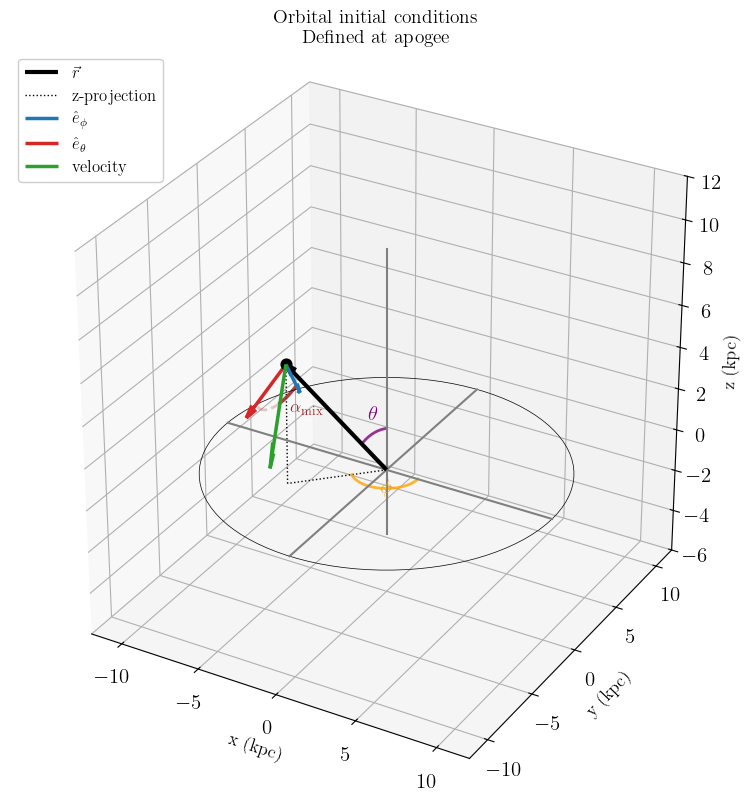

In [9]:
# galaxy
MWparams                = tstrippy.Parsers.pouliasis2017pii()
G = MWparams[0]
# cluster
cluster_mass            = 5e5      # solar masses
cluster_half_mass_radius= 5e-3   # kpc
cluster_num_partilces   = int(1e2)
cluster_char_radius     = tstrippy.ergodic.convertHalfMassRadiusToPlummerRadius(cluster_half_mass_radius)
# populate the sphere
xp,yp,zp,vxp,vyp,vzp = tstrippy.ergodic.isotropicplummer(G,cluster_mass,cluster_half_mass_radius,cluster_num_partilces)
# the orbit 
radius = 8
eccen = 0.2
theta = np.pi/4
phi =-3*np.pi/4
polar_mix = np.pi/6
rvec,vvec,azimuthal,meridional = apoapsis_shot(tstrippy.potentials.pouliasis2017pii, MWparams, radius, eccen, theta, phi, polar_mix, getVecs=True)
fig, ax=plot_initial_orbital_conditions_geometry(rvec,vvec,azimuthal,meridional,theta,phi,polar_mix)


## Obtain integration parameters
Let the total integration time be based on the cross time of the galaxy

$$ T = \sqrt{\frac{a_{\rm{halo}}}{\rm{GM_{halo}}}}$$

The time-step should be based on the internal dynamical time of the globular cluster

$$ \tau = \sqrt{\frac{\rm{a_{cluster}}^3}{\rm{GM_{cluster}}}}$$

Of course, you are free to pick a desired time for the total integration time. If you wish to integrate for X billion years or Y million years, remember that you must convert to the integration units: s kpc / km. This easily done with astropy's unit module. Note that the timestep has to be smaller than the internal dynamical time of the cluster. 

In [29]:
# user sets the resolution and total integration time 
factor_dt = 1e-2
factor_n_gal_characteristic_times = 10
halo_mass_param = MWparams[1]
halo_char_radius = MWparams[2]
# compute the characteristic times 
Tcross = np.sqrt(halo_char_radius**3 / (G*halo_mass_param))
tau = np.sqrt(cluster_char_radius**3 / (G*cluster_mass))
# set the integration parameters 
dt = factor_dt*tau
integration_time = factor_n_gal_characteristic_times*Tcross
NSTEP = int(integration_time / dt)
# update the integration time to make sure that it is a multiple of NSTEPS
integration_time = dt*NSTEP
print("{:20s}: {:14.2f} s kpc / km".format("integration time", integration_time))
print("{:20s}: {:14.9f} s kpc / km".format("time step", dt))
# convert to years 
from astropy import units as u 
unitT = u.s * u.kpc / u.km 
dt_years = (dt*unitT).to(u.yr)
integration_time_years = (integration_time*unitT).to(u.Myr)
print("----- in years -----")
print("{:20s}: {:14.0f} ".format("integration time", integration_time_years))
print("{:20s}: {:14.0f} ".format("time step", dt_years))
print("")
print("{:20s}: {:14d} ".format("Number of steps", NSTEP))


integration time    :           0.55 s kpc / km
time step           :    0.000001618 s kpc / km
----- in years -----
integration time    :            540 Myr 
time step           :           1582 yr 

Number of steps     :         341708 


## Integrate the orbit of the globular cluster

The cluster orbit is integrated **backward** from today (t = 0) to an earlier epoch. This gives us the trajectory the cluster must have followed to arrive at the chosen position today. The same trajectory, read forward in time, is then used as the moving host potential during stream generation.

In [11]:
staticgalaxy = ["pouliasis2017pii", MWparams]

# You can now choose independent resolutions.
host_dt = dt
host_nstep = NSTEP
particle_dt = dt
particle_nstep = NSTEP


# 1. Integrate the host orbit once.
host_orbit = integrate_orbit(
    staticgalaxy=staticgalaxy,
    initial_kinematics=[*rvec, *vvec],
    integration_params=[0,host_dt,host_nstep],
    backward=True,
)

# 2. Build the host kinematics for the forward stripping run.
# sample_stride is the knob you can vary to make the host more coarsely sampled.
host_forward = make_host_kinematics(
    host_orbit,
    sample_stride=1,
    target_time_order="increasing",
)

# Populate particles around the host starting point.
initial_stream_kinematics = [
    xp + host_forward["x"][0],
    yp + host_forward["y"][0],
    zp + host_forward["z"][0],
    vxp + host_forward["vx"][0],
    vyp + host_forward["vy"][0],
    vzp + host_forward["vz"][0],
]

hostmass = ["constant", cluster_mass]
hostradius = cluster_char_radius

# 3. Run the stream forward in the supplied host trajectory.
stream = integrate_particles_in_host(
    staticgalaxy=staticgalaxy,
    initial_kinematics=initial_stream_kinematics,
    t0=host_forward["time"][0],
    dt=particle_dt,
    nstep=particle_nstep,
    hostkinematics=host_forward,
    hostmass=hostmass,
    hostradius=hostradius,
    backward=False,
)

xf = stream["xf"]
yf = stream["yf"]
zf = stream["zf"]
vxf = stream["vxf"]
vyf = stream["vyf"]
vzf = stream["vzf"]

# 4. Build the host kinematics for the backward retrace.
host_backward = make_host_kinematics(
    host_orbit,
    sample_stride=1,
    target_time_order="decreasing",
)

# 5. Retrace the stream backward.
retrace = integrate_particles_in_host(
    staticgalaxy=staticgalaxy,
    initial_kinematics=[xf, yf, zf, vxf, vyf, vzf],
    t0=0.0,
    dt=particle_dt,
    nstep=particle_nstep,
    hostkinematics=host_backward,
    hostmass=hostmass,
    hostradius=hostradius,
    backward=True,
)

x0 = retrace["xf"]
y0 = retrace["yf"]
z0 = retrace["zf"]
vx0 = retrace["vxf"]
vy0 = retrace["vyf"]
vz0 = retrace["vzf"]

# Optional aliases so your existing plotting cell still works.
timestamps = host_forward["time"]
xt = host_forward["x"]
yt = host_forward["y"]
zt = host_forward["z"]
vxt = host_forward["vx"]
vyt = host_forward["vy"]
vzt = host_forward["vz"]

## Results

The left panel shows the stream (red) spread along the host orbit (blue line), with the retrace (black) overlaid on the initial cluster positions. The inset zooms in on the initial position to show how closely the retrace recovers the starting conditions.

The right panel shows the distribution of fractional energy error $\left| (E_{\rm retrace} - E_0) / E_0 \right|$ across all particles. A well-behaved leapfrog integrator should produce errors $\lesssim 10^{-4}$ for the timestep chosen here.

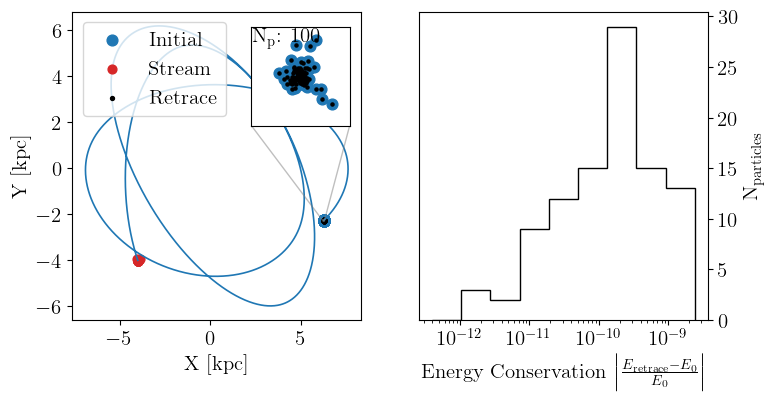

In [12]:
initial = [initial_stream_kinematics[0],initial_stream_kinematics[1]]
orbit = [xt, yt]
stream = [xf, yf]
retrace = [x0, y0]
final = [x0,y0,z0,vx0,vy0,vz0]
energyerror = compute_energy_error(tstrippy.potentials.pouliasis2017pii,MWparams,initial_stream_kinematics,final)
nbins = int(np.sqrt(energyerror.shape[0]))
AXIS = {"xlabel": r"Energy Conservation $\left| \frac{ E_{\rm{retrace}}-E_0} { E_0} \right|$", "xscale": "log","ylabel":r"$\rm{N}_{\rm{particles}}$"}
bins=np.logspace(np.log10(energyerror.min()), np.log10(energyerror.max()), nbins)

fig, axis, axins = plot_stream_retrace(
    orbit, initial, stream, retrace,
    nparticles=cluster_num_partilces,
    nskip=100,figsize=(8.2,4)
)
axis[1].hist(energyerror,bins=bins, histtype='step', color="k")
axis[1].set(**AXIS)
axis[1].yaxis.set_label_position("right")
axis[1].yaxis.tick_right()


## Summary

This notebook confirms that the leapfrog integrator in `tstrippy` respects time-reversal symmetry. Starting from a Plummer sphere, stripping a stream forward over 10 galactic crossing times, and retracing backward recovers the initial phase-space coordinates to within numerical truncation error. This gives confidence that the stream generation workflow is correctly implemented.